# NB05 — Training Pipeline & Baseline Training
## EPGT Research Pipeline | Emoji Pragmatic Graph Transformer

---

### Tujuan Notebook

Notebook ini mengimplementasikan training pipeline lengkap dan melatih semua konfigurasi model:

**Tahap 1 — Training Infrastructure**
- MTL Loss: `L_total = 0.40·L_intensity + 0.35·L_sarcasm + 0.25·L_role`
- AdamW optimizer, LR=2e-5, weight decay=0.01
- Linear warmup scheduler (10% steps)
- Early stopping (patience=3, monitor=val_macro_f1)
- Checkpoint manager ke Google Drive

**Tahap 2 — Baseline Models (B1, B2, B3)**
- B1: IndoBERT text-only (≡ ABL-3: no_emoji)
- B2: IndoBERT + fine-tune per-task (single-task, tanpa MTL)
- B3: IndoBERT + emoji sebagai teks biasa (flat token)

**Tahap 3 — Full EPGT Training**
- Full EPGT (ABL-5): semua komponen aktif

---

### Output
```
EPGT_Research/checkpoints/
├── baseline_b1/  best_model.pt, training_log.json
├── baseline_b2/  best_model.pt, training_log.json
├── baseline_b3/  best_model.pt, training_log.json
└── epgt_full/    best_model.pt, training_log.json
```

**Blueprint Reference:** Section 4.1 Training Configuration, Section 4.2 Baseline Models

---
## BAGIAN 1 — ENVIRONMENT SETUP

In [1]:
# ============================================================
# CELL 1.1 — Install Dependencies
# ============================================================

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q torch-geometric
!pip install -q transformers
!pip install -q emoji pandas numpy tqdm scikit-learn

import torch
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device   : {DEVICE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 37.9 MB/s eta 0:00:00
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB
Device   : cuda


In [2]:
# ============================================================
# CELL 1.2 — Mount Drive & Setup Path
# ============================================================

from google.colab import drive
import sys
from pathlib import Path

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/EPGT_Research")
SRC_PATH   = str(DRIVE_ROOT / "src")

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

RANDOM_SEED = 42

# Set seeds
import random, numpy as np, torch
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"Drive Root : {DRIVE_ROOT}")
print(f"Seed       : {RANDOM_SEED}")

Mounted at /content/drive
Drive Root : /content/drive/MyDrive/EPGT_Research
Seed       : 42


---
## BAGIAN 2 — TRAINING INFRASTRUCTURE (src/training/)

In [3]:
# ============================================================
# CELL 2.1 — Tulis loss.py
# ============================================================

LOSS_CODE = '''"""
loss.py — MTL Loss untuk EPGT.

L_total = λ_A · L_intensity + λ_B · L_sarcasm + λ_C · L_role
λ_A=0.40, λ_B=0.35, λ_C=0.25 (blueprint Section 4.1)

Semua sub-loss menggunakan CrossEntropyLoss dengan label_smoothing=0.1.
"""

import torch
import torch.nn as nn
from typing import Dict, Tuple


class EPGTLoss(nn.Module):
    """
    Weighted MTL loss untuk 3 task EPGT.

    Args:
        lambda_intensity : bobot L_intensity (default 0.40)
        lambda_sarcasm   : bobot L_sarcasm   (default 0.35)
        lambda_role      : bobot L_role      (default 0.25)
        label_smoothing  : label smoothing (default 0.10)
        ignore_index     : label yang diabaikan (default -1)
    """

    def __init__(
        self,
        lambda_intensity: float = 0.40,
        lambda_sarcasm  : float = 0.35,
        lambda_role     : float = 0.25,
        label_smoothing : float = 0.10,
        ignore_index    : int   = -1,
    ):
        super().__init__()

        total = lambda_intensity + lambda_sarcasm + lambda_role
        assert abs(total - 1.0) < 1e-6, f"Lambda harus berjumlah 1.0, got {total}"

        self.lambda_intensity = lambda_intensity
        self.lambda_sarcasm   = lambda_sarcasm
        self.lambda_role      = lambda_role

        self.criterion = nn.CrossEntropyLoss(
            label_smoothing = label_smoothing,
            ignore_index    = ignore_index,
        )

    def forward(
        self,
        logits_intensity : torch.Tensor,
        logits_sarcasm   : torch.Tensor,
        logits_role      : torch.Tensor,
        labels_intensity : torch.Tensor,
        labels_sarcasm   : torch.Tensor,
        labels_role      : torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        """
        Hitung total MTL loss.

        Returns:
            total_loss : scalar tensor untuk backward()
            loss_dict  : dict dengan sub-loss values (untuk logging)
        """
        L_intensity = self.criterion(logits_intensity, labels_intensity)
        L_sarcasm   = self.criterion(logits_sarcasm,   labels_sarcasm)
        L_role      = self.criterion(logits_role,      labels_role)

        total_loss = (
            self.lambda_intensity * L_intensity +
            self.lambda_sarcasm   * L_sarcasm   +
            self.lambda_role      * L_role
        )

        loss_dict = {
            "loss_total"    : total_loss.item(),
            "loss_intensity": L_intensity.item(),
            "loss_sarcasm"  : L_sarcasm.item(),
            "loss_role"     : L_role.item(),
        }

        return total_loss, loss_dict
'''

(DRIVE_ROOT / "src/training").mkdir(parents=True, exist_ok=True)
path = DRIVE_ROOT / "src/training/loss.py"
path.write_text(LOSS_CODE, encoding="utf-8")
print(f"loss.py saved ({path.stat().st_size:,} bytes)")

loss.py saved (2,579 bytes)


In [4]:
# ============================================================
# CELL 2.2 — Tulis metrics.py
# ============================================================

METRICS_CODE = '''"""
metrics.py — Evaluation metrics untuk EPGT.

Primary metric : Macro F1 (average=macro) per task
Secondary      : Accuracy, Weighted F1
Aggregated     : avg_macro_f1 = mean(f1_intensity, f1_sarcasm, f1_role)

Digunakan untuk early stopping dan checkpoint selection.
"""

import numpy as np
from typing import Dict, List
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report
)


class EPGTMetrics:
    """
    Evaluasi metrics untuk 3 task EPGT.

    Primary metric untuk model selection: avg_macro_f1
    (rata-rata Macro F1 dari ketiga task)
    """

    TASK_NAMES = {
        "intensity" : "Emotion Intensity",
        "sarcasm"   : "Sarcasm Detection",
        "role"      : "Emoji Role",
    }

    LABEL_NAMES = {
        "intensity" : ["Low", "Medium", "High"],
        "sarcasm"   : ["Non-Sarcastic", "Sarcastic"],
        "role"      : ["Literal", "Exaggeration", "Irony", "Reaction"],
    }

    def compute(
        self,
        preds_intensity : List[int],
        preds_sarcasm   : List[int],
        preds_role      : List[int],
        labels_intensity: List[int],
        labels_sarcasm  : List[int],
        labels_role     : List[int],
    ) -> Dict:
        """
        Hitung semua metrics.

        Returns:
            dict dengan metrics per task + aggregated avg_macro_f1
        """
        results = {}
        macro_f1s = []

        task_data = [
            ("intensity", preds_intensity, labels_intensity),
            ("sarcasm",   preds_sarcasm,   labels_sarcasm),
            ("role",      preds_role,      labels_role),
        ]

        for task, preds, labels in task_data:
            preds_arr  = np.array(preds)
            labels_arr = np.array(labels)

            macro_f1 = f1_score(labels_arr, preds_arr, average="macro",
                                zero_division=0)
            weighted_f1 = f1_score(labels_arr, preds_arr, average="weighted",
                                   zero_division=0)
            acc = accuracy_score(labels_arr, preds_arr)

            results[f"f1_macro_{task}"]    = round(macro_f1, 4)
            results[f"f1_weighted_{task}"] = round(weighted_f1, 4)
            results[f"acc_{task}"]         = round(acc, 4)
            macro_f1s.append(macro_f1)

        # Aggregated metric — digunakan untuk early stopping
        results["avg_macro_f1"] = round(float(np.mean(macro_f1s)), 4)

        return results

    def get_classification_reports(
        self,
        preds_intensity : List[int],
        preds_sarcasm   : List[int],
        preds_role      : List[int],
        labels_intensity: List[int],
        labels_sarcasm  : List[int],
        labels_role     : List[int],
    ) -> Dict[str, str]:
        """Buat classification report per task."""
        reports = {}
        task_data = [
            ("intensity", preds_intensity, labels_intensity),
            ("sarcasm",   preds_sarcasm,   labels_sarcasm),
            ("role",      preds_role,      labels_role),
        ]
        for task, preds, labels in task_data:
            reports[task] = classification_report(
                labels, preds,
                target_names = self.LABEL_NAMES[task],
                zero_division= 0,
            )
        return reports
'''

path = DRIVE_ROOT / "src/training/metrics.py"
path.write_text(METRICS_CODE, encoding="utf-8")
print(f"metrics.py saved ({path.stat().st_size:,} bytes)")

metrics.py saved (3,259 bytes)


In [5]:
# ============================================================
# CELL 2.3 — Tulis trainer.py
# ============================================================

TRAINER_CODE = '''"""
trainer.py — Training loop untuk EPGT.

Fitur:
  - AdamW optimizer + linear warmup scheduler
  - Gradient clipping (max_norm=1.0)
  - Early stopping (patience=3, monitor=avg_macro_f1)
  - Checkpoint save/load ke Google Drive
  - Training log (JSON) per epoch
  - Gradient accumulation support
"""

import json
import time
import logging
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from typing import Dict, List, Optional
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from torch_geometric.data import Batch

from training.loss    import EPGTLoss
from training.metrics import EPGTMetrics

logger = logging.getLogger(__name__)


class EPGTTrainer:
    """
    Training loop untuk EPGT dan semua baseline.

    Args:
        model           : EPGTModel atau baseline model
        train_loader    : DataLoader untuk training set
        val_loader      : DataLoader untuk validation set
        checkpoint_dir  : Path untuk menyimpan checkpoint
        lr              : learning rate (default 2e-5)
        weight_decay    : AdamW weight decay (default 0.01)
        max_epochs      : maksimum epoch (default 20)
        patience        : early stopping patience (default 3)
        warmup_ratio    : proporsi warmup steps (default 0.10)
        grad_clip       : gradient clipping max norm (default 1.0)
        accum_steps     : gradient accumulation steps (default 1)
        device          : torch device
        run_name        : nama run untuk logging
    """

    def __init__(
        self,
        model          : nn.Module,
        train_loader   : DataLoader,
        val_loader     : DataLoader,
        checkpoint_dir : str,
        lr             : float = 2e-5,
        weight_decay   : float = 0.01,
        max_epochs     : int   = 20,
        patience       : int   = 3,
        warmup_ratio   : float = 0.10,
        grad_clip      : float = 1.0,
        accum_steps    : int   = 1,
        device         : Optional[torch.device] = None,
        run_name       : str   = "epgt",
        lambda_intensity: float = 0.40,
        lambda_sarcasm  : float = 0.35,
        lambda_role     : float = 0.25,
    ):
        self.model          = model
        self.train_loader   = train_loader
        self.val_loader     = val_loader
        self.checkpoint_dir = Path(checkpoint_dir)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.lr             = lr
        self.weight_decay   = weight_decay
        self.max_epochs     = max_epochs
        self.patience       = patience
        self.grad_clip      = grad_clip
        self.accum_steps    = accum_steps
        self.device         = device or torch.device("cpu")
        self.run_name       = run_name

        self.loss_fn = EPGTLoss(
            lambda_intensity = lambda_intensity,
            lambda_sarcasm   = lambda_sarcasm,
            lambda_role      = lambda_role,
        )
        self.metrics = EPGTMetrics()

        # Optimizer
        # Pisahkan BERT params (lr rendah) dari non-BERT params
        bert_params = []
        other_params= []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if "text_encoder.bert" in name:
                bert_params.append(param)
            else:
                other_params.append(param)

        self.optimizer = AdamW(
            [
                {"params": bert_params,  "lr": lr},
                {"params": other_params, "lr": lr * 10},  # 10x untuk non-BERT
            ],
            weight_decay = weight_decay,
        )

        # Scheduler: linear warmup
        total_steps   = len(train_loader) * max_epochs // accum_steps
        warmup_steps  = int(total_steps * warmup_ratio)
        self.scheduler= get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps   = warmup_steps,
            num_training_steps = total_steps,
        )

        # State
        self.best_val_metric = 0.0
        self.best_epoch      = 0
        self.no_improve_count= 0
        self.training_log    = []

    def _train_epoch(self, epoch: int) -> Dict:
        """Satu epoch training."""
        self.model.train()
        total_loss  = 0.0
        loss_counts = {"loss_intensity": 0.0, "loss_sarcasm": 0.0, "loss_role": 0.0}
        n_batches   = 0

        self.optimizer.zero_grad()

        for step, batch in enumerate(self.train_loader):
            # Pindahkan ke device
            input_ids      = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(self.device)

            graph_batch    = batch["graph"].to(self.device)

            labels_intensity= batch["label_intensity"].to(self.device)
            labels_sarcasm  = batch["label_sarcasm"].to(self.device)
            labels_role     = batch["label_emoji_role"].to(self.device)

            # Forward
            outputs = self.model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                graph_batch    = graph_batch,
                token_type_ids = token_type_ids,
            )

            # Loss
            loss, loss_dict = self.loss_fn(
                logits_intensity = outputs["logits_intensity"],
                logits_sarcasm   = outputs["logits_sarcasm"],
                logits_role      = outputs["logits_role"],
                labels_intensity = labels_intensity,
                labels_sarcasm   = labels_sarcasm,
                labels_role      = labels_role,
            )

            loss = loss / self.accum_steps
            loss.backward()

            if (step + 1) % self.accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(), self.grad_clip
                )
                self.optimizer.step()
                self.scheduler.step()
                self.optimizer.zero_grad()

            total_loss += loss_dict["loss_total"]
            for k in loss_counts:
                loss_counts[k] += loss_dict.get(k, 0.0)
            n_batches += 1

        avg_loss = {k: v / n_batches for k, v in loss_counts.items()}
        avg_loss["loss_total"] = total_loss / n_batches
        return avg_loss

    @torch.no_grad()
    def _evaluate(self, loader: DataLoader) -> Dict:
        """Evaluasi model pada satu DataLoader."""
        self.model.eval()

        all_preds  = {"intensity": [], "sarcasm": [], "role": []}
        all_labels = {"intensity": [], "sarcasm": [], "role": []}
        total_loss = 0.0
        n_batches  = 0

        for batch in loader:
            input_ids      = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(self.device)

            graph_batch     = batch["graph"].to(self.device)
            labels_intensity= batch["label_intensity"].to(self.device)
            labels_sarcasm  = batch["label_sarcasm"].to(self.device)
            labels_role     = batch["label_emoji_role"].to(self.device)

            outputs = self.model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                graph_batch    = graph_batch,
                token_type_ids = token_type_ids,
            )

            loss, _ = self.loss_fn(
                logits_intensity = outputs["logits_intensity"],
                logits_sarcasm   = outputs["logits_sarcasm"],
                logits_role      = outputs["logits_role"],
                labels_intensity = labels_intensity,
                labels_sarcasm   = labels_sarcasm,
                labels_role      = labels_role,
            )
            total_loss += loss.item()
            n_batches  += 1

            # Predictions (argmax)
            all_preds["intensity"].extend(
                outputs["logits_intensity"].argmax(dim=-1).cpu().tolist()
            )
            all_preds["sarcasm"].extend(
                outputs["logits_sarcasm"].argmax(dim=-1).cpu().tolist()
            )
            all_preds["role"].extend(
                outputs["logits_role"].argmax(dim=-1).cpu().tolist()
            )
            all_labels["intensity"].extend(labels_intensity.cpu().tolist())
            all_labels["sarcasm"].extend(labels_sarcasm.cpu().tolist())
            all_labels["role"].extend(labels_role.cpu().tolist())

        metrics = self.metrics.compute(
            preds_intensity  = all_preds["intensity"],
            preds_sarcasm    = all_preds["sarcasm"],
            preds_role       = all_preds["role"],
            labels_intensity = all_labels["intensity"],
            labels_sarcasm   = all_labels["sarcasm"],
            labels_role      = all_labels["role"],
        )
        metrics["val_loss"] = total_loss / n_batches
        return metrics

    def _save_checkpoint(self, epoch: int, metrics: Dict) -> None:
        """Simpan best model checkpoint ke Drive."""
        ckpt = {
            "epoch"       : epoch,
            "model_state" : self.model.state_dict(),
            "optim_state" : self.optimizer.state_dict(),
            "metrics"     : metrics,
            "run_name"    : self.run_name,
        }
        path = self.checkpoint_dir / "best_model.pt"
        torch.save(ckpt, str(path))
        logger.info(f"Checkpoint saved: {path}")

    def _save_log(self) -> None:
        path = self.checkpoint_dir / "training_log.json"
        with open(path, "w") as f:
            json.dump(self.training_log, f, indent=2)

    def train(self) -> Dict:
        """
        Full training loop dengan early stopping.

        Returns:
            best_metrics dari epoch terbaik
        """
        print(f"Training [{self.run_name}]")
        print(f"  Epochs    : {self.max_epochs} (patience={self.patience})")
        print(f"  Optimizer : AdamW (lr={self.lr}, wd={self.weight_decay})")
        print(f"  Device    : {self.device}")
        print(f"  Checkpoint: {self.checkpoint_dir}")
        print()

        best_metrics = {}

        for epoch in range(1, self.max_epochs + 1):
            t0 = time.time()

            # Train
            train_loss = self._train_epoch(epoch)

            # Validate
            val_metrics = self._evaluate(self.val_loader)
            val_metric  = val_metrics["avg_macro_f1"]

            elapsed = time.time() - t0

            # Log
            epoch_log = {
                "epoch"           : epoch,
                "train_loss"      : round(train_loss["loss_total"], 4),
                "val_loss"        : round(val_metrics["val_loss"], 4),
                "avg_macro_f1"    : round(val_metric, 4),
                "f1_intensity"    : val_metrics["f1_macro_intensity"],
                "f1_sarcasm"      : val_metrics["f1_macro_sarcasm"],
                "f1_role"         : val_metrics["f1_macro_role"],
                "elapsed_sec"     : round(elapsed, 1),
            }
            self.training_log.append(epoch_log)
            self._save_log()

            # Print progress
            improved = "*" if val_metric > self.best_val_metric else ""
            print(
                f"  Epoch {epoch:>2}/{self.max_epochs} "
                f"| train_loss={train_loss['loss_total']:.4f} "
                f"| val_loss={val_metrics['val_loss']:.4f} "
                f"| avg_f1={val_metric:.4f} "
                f"| f1=[{val_metrics['f1_macro_intensity']:.3f}, "
                f"{val_metrics['f1_macro_sarcasm']:.3f}, "
                f"{val_metrics['f1_macro_role']:.3f}] "
                f"| {elapsed:.0f}s {improved}"
            )

            # Best model check
            if val_metric > self.best_val_metric:
                self.best_val_metric  = val_metric
                self.best_epoch       = epoch
                self.no_improve_count = 0
                best_metrics          = val_metrics.copy()
                self._save_checkpoint(epoch, val_metrics)
            else:
                self.no_improve_count += 1

            # Early stopping
            if self.no_improve_count >= self.patience:
                print(f"\n  Early stopping at epoch {epoch} "
                      f"(no improvement for {self.patience} epochs)")
                break

        print(f"\nBest epoch : {self.best_epoch}")
        print(f"Best avg_macro_f1 : {self.best_val_metric:.4f}")

        return best_metrics
'''

path = DRIVE_ROOT / "src/training/trainer.py"
path.write_text(TRAINER_CODE, encoding="utf-8")
print(f"trainer.py saved ({path.stat().st_size:,} bytes)")

trainer.py saved (12,735 bytes)


---
## BAGIAN 3 — EPGT DATASET & DATALOADER

In [6]:
# ============================================================
# CELL 3.1 — Tulis dataset.py
# ============================================================

DATASET_CODE = '''"""
dataset.py — PyTorch Dataset untuk EPGT.

Menggabungkan text tokenization data dari preprocessor.py
dengan graph objects dari emoji_graph.py.

Output per item:
  input_ids      : LongTensor (128,)
  attention_mask : LongTensor (128,)
  token_type_ids : LongTensor (128,)
  graph          : torch_geometric.data.Data
  label_intensity: LongTensor ()
  label_sarcasm  : LongTensor ()
  label_emoji_role: LongTensor ()
"""

import ast
import torch
import pandas as pd
from pathlib import Path
from typing import Dict, List, Optional
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch


class EPGTDataset(Dataset):
    """
    Dataset yang menggabungkan text features dan graph objects.

    Args:
        df     : processed DataFrame dari preprocessor
        graphs : list of torch_geometric.data.Data objects
    """

    def __init__(
        self,
        df    : pd.DataFrame,
        graphs: List[Data],
    ):
        assert len(df) == len(graphs), \
            f"DataFrame ({len(df)}) dan graphs ({len(graphs)}) harus sama panjang"

        self.df     = df.reset_index(drop=True)
        self.graphs = graphs

        # Parse tokenization columns dari string
        self._input_ids       = self._parse_col("input_ids")
        self._attention_mask  = self._parse_col("attention_mask")
        self._token_type_ids  = self._parse_col("token_type_ids")

    def _parse_col(self, col: str) -> List[List[int]]:
        """Parse kolom yang tersimpan sebagai string list."""
        result = []
        for val in self.df[col]:
            if isinstance(val, str):
                try:
                    parsed = ast.literal_eval(val)
                except Exception:
                    parsed = [0] * 128
            elif isinstance(val, list):
                parsed = val
            else:
                parsed = [0] * 128
            result.append(parsed)
        return result

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict:
        row = self.df.iloc[idx]

        return {
            "input_ids"       : torch.tensor(self._input_ids[idx],      dtype=torch.long),
            "attention_mask"  : torch.tensor(self._attention_mask[idx], dtype=torch.long),
            "token_type_ids"  : torch.tensor(self._token_type_ids[idx], dtype=torch.long),
            "graph"           : self.graphs[idx],
            "label_intensity" : torch.tensor(int(row["label_intensity"]),  dtype=torch.long),
            "label_sarcasm"   : torch.tensor(int(row["label_sarcasm"]),    dtype=torch.long),
            "label_emoji_role": torch.tensor(int(row["label_emoji_role"]), dtype=torch.long),
        }


def epgt_collate_fn(batch: List[Dict]) -> Dict:
    """
    Custom collate function untuk DataLoader.
    Graph objects di-batch menggunakan PyG Batch.from_data_list.
    """
    return {
        "input_ids"       : torch.stack([b["input_ids"]        for b in batch]),
        "attention_mask"  : torch.stack([b["attention_mask"]   for b in batch]),
        "token_type_ids"  : torch.stack([b["token_type_ids"]   for b in batch]),
        "graph"           : Batch.from_data_list([b["graph"]   for b in batch]),
        "label_intensity" : torch.stack([b["label_intensity"]  for b in batch]),
        "label_sarcasm"   : torch.stack([b["label_sarcasm"]    for b in batch]),
        "label_emoji_role": torch.stack([b["label_emoji_role"] for b in batch]),
    }


def build_dataloaders(
    df_train : pd.DataFrame,
    df_val   : pd.DataFrame,
    df_test  : pd.DataFrame,
    graphs_train: List[Data],
    graphs_val  : List[Data],
    graphs_test : List[Data],
    batch_size  : int = 16,
    num_workers : int = 0,
) -> Dict[str, DataLoader]:
    """
    Buat DataLoaders untuk train, val, test.

    Args:
        batch_size  : batch size untuk training (default 16)
        num_workers : num_workers DataLoader (Colab: 0)
    """
    train_dataset = EPGTDataset(df_train, graphs_train)
    val_dataset   = EPGTDataset(df_val,   graphs_val)
    test_dataset  = EPGTDataset(df_test,  graphs_test)

    return {
        "train": DataLoader(
            train_dataset,
            batch_size  = batch_size,
            shuffle     = True,
            collate_fn  = epgt_collate_fn,
            num_workers = num_workers,
            drop_last   = False,
        ),
        "val": DataLoader(
            val_dataset,
            batch_size  = batch_size * 2,
            shuffle     = False,
            collate_fn  = epgt_collate_fn,
            num_workers = num_workers,
        ),
        "test": DataLoader(
            test_dataset,
            batch_size  = batch_size * 2,
            shuffle     = False,
            collate_fn  = epgt_collate_fn,
            num_workers = num_workers,
        ),
    }
'''

path = DRIVE_ROOT / "src/data/dataset.py"
path.write_text(DATASET_CODE, encoding="utf-8")
print(f"dataset.py saved ({path.stat().st_size:,} bytes)")

dataset.py saved (4,823 bytes)


---
## BAGIAN 4 — LOAD DATA & BUILD DATALOADERS

In [7]:
# ============================================================
# CELL 4.1 — Load Data & Build DataLoaders
# ============================================================

import pickle
import pandas as pd
from importlib import reload

import data.dataset as ds_mod
reload(ds_mod)

# Load processed splits
df_train = pd.read_csv(DRIVE_ROOT / "data/processed/train_processed.csv")
df_val   = pd.read_csv(DRIVE_ROOT / "data/processed/val_processed.csv")
df_test  = pd.read_csv(DRIVE_ROOT / "data/processed/test_processed.csv")

# Load graph objects
def load_graphs(split_name):
    path = DRIVE_ROOT / f"data/features/graph_objects/{split_name}_graphs.pkl"
    with open(path, "rb") as f:
        return pickle.load(f)

graphs_train = load_graphs("train")
graphs_val   = load_graphs("val")
graphs_test  = load_graphs("test")

print(f"Data loaded:")
print(f"  Train : {len(df_train):,} samples, {len(graphs_train)} graphs")
print(f"  Val   : {len(df_val):,} samples, {len(graphs_val)} graphs")
print(f"  Test  : {len(df_test):,} samples, {len(graphs_test)} graphs")

# Build DataLoaders
BATCH_SIZE = 16
loaders = ds_mod.build_dataloaders(
    df_train     = df_train,
    df_val       = df_val,
    df_test      = df_test,
    graphs_train = graphs_train,
    graphs_val   = graphs_val,
    graphs_test  = graphs_test,
    batch_size   = BATCH_SIZE,
    num_workers  = 0,
)

print(f"\nDataLoaders built:")
for split, loader in loaders.items():
    print(f"  {split:<6}: {len(loader)} batches (batch_size={loader.batch_size})")

# Verifikasi satu batch
sample_batch = next(iter(loaders["train"]))
print(f"\nSample batch keys    : {list(sample_batch.keys())}")
print(f"  input_ids shape    : {sample_batch['input_ids'].shape}")
print(f"  graph.x shape      : {sample_batch['graph'].x.shape}")
print(f"  label_intensity    : {sample_batch['label_intensity']}")

Data loaded:
  Train : 56 samples, 56 graphs
  Val   : 12 samples, 12 graphs
  Test  : 12 samples, 12 graphs

DataLoaders built:
  train : 4 batches (batch_size=16)
  val   : 1 batches (batch_size=32)
  test  : 1 batches (batch_size=32)

Sample batch keys    : ['input_ids', 'attention_mask', 'token_type_ids', 'graph', 'label_intensity', 'label_sarcasm', 'label_emoji_role']
  input_ids shape    : torch.Size([16, 128])
  graph.x shape      : torch.Size([29, 203])
  label_intensity    : tensor([1, 0, 1, 0, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2])


---
## BAGIAN 5 — TRAINING: BASELINE & FULL EPGT

In [8]:
# ============================================================
# CELL 5.1 — Definisi Training Configurations
# ============================================================

# Konfigurasi semua model yang akan dilatih
# Urutan: B1 → B3 → Full EPGT
# B2 (single-task) dilatih per-task secara terpisah di Cell 5.3

TRAINING_CONFIGS = [
    {
        "run_name"      : "baseline_b1",
        "description"   : "B1: IndoBERT text-only (ABL-3: no_emoji)",
        "ablation_mode" : "no_emoji",
        "max_epochs"    : 10,
        "lr"            : 2e-5,
    },
    {
        "run_name"      : "baseline_b3",
        "description"   : "B3: IndoBERT + flat emoji token",
        "ablation_mode" : "no_graph",   # pakai teks dengan emoji tapi tanpa graph
        "max_epochs"    : 10,
        "lr"            : 2e-5,
    },
    {
        "run_name"      : "epgt_full",
        "description"   : "Full EPGT (ABL-5 reference)",
        "ablation_mode" : None,
        "max_epochs"    : 20,
        "lr"            : 2e-5,
    },
]

print("Training Configurations:")
for cfg in TRAINING_CONFIGS:
    print(f"  {cfg['run_name']:<18}: {cfg['description']}")
    print(f"  {'':18}  ablation={cfg['ablation_mode']}, "
          f"max_epochs={cfg['max_epochs']}, lr={cfg['lr']}")

Training Configurations:
  baseline_b1       : B1: IndoBERT text-only (ABL-3: no_emoji)
                      ablation=no_emoji, max_epochs=10, lr=2e-05
  baseline_b3       : B3: IndoBERT + flat emoji token
                      ablation=no_graph, max_epochs=10, lr=2e-05
  epgt_full         : Full EPGT (ABL-5 reference)
                      ablation=None, max_epochs=20, lr=2e-05


In [14]:
# ============================================================
# CELL 5.1b — Tulis Ulang trainer.py (Full Rewrite, FIXED)
# ============================================================

TRAINER_CODE_FIXED = """
import json, time, logging
import torch
import torch.nn as nn
from pathlib import Path
from typing import Dict, Optional
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

from training.loss    import EPGTLoss
from training.metrics import EPGTMetrics

logger = logging.getLogger(__name__)


class EPGTTrainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        checkpoint_dir,
        lr               = 2e-5,
        weight_decay     = 0.01,
        max_epochs       = 20,
        patience         = 3,
        warmup_ratio     = 0.10,
        grad_clip        = 1.0,
        accum_steps      = 1,
        device           = None,
        run_name         = "epgt",
        lambda_intensity = 0.40,
        lambda_sarcasm   = 0.35,
        lambda_role      = 0.25,
    ):
        self.model          = model
        self.train_loader   = train_loader
        self.val_loader     = val_loader
        self.checkpoint_dir = Path(checkpoint_dir)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.lr             = lr
        self.weight_decay   = weight_decay
        self.max_epochs     = max_epochs
        self.patience       = patience
        self.grad_clip      = grad_clip
        self.accum_steps    = accum_steps
        self.device         = device or torch.device("cpu")
        self.run_name       = run_name

        self.loss_fn = EPGTLoss(
            lambda_intensity = lambda_intensity,
            lambda_sarcasm   = lambda_sarcasm,
            lambda_role      = lambda_role,
        )
        self.metrics = EPGTMetrics()

        bert_params, other_params = [], []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if "text_encoder.bert" in name:
                bert_params.append(param)
            else:
                other_params.append(param)

        self.optimizer = AdamW(
            [
                {"params": bert_params,  "lr": lr},
                {"params": other_params, "lr": lr * 10},
            ],
            weight_decay = weight_decay,
        )

        total_steps  = len(train_loader) * max_epochs // accum_steps
        warmup_steps = int(total_steps * warmup_ratio)
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps   = warmup_steps,
            num_training_steps = total_steps,
        )

        self.best_val_metric  = 0.0
        self.best_epoch       = 0
        self.no_improve_count = 0
        self.training_log     = []

    def _train_epoch(self, epoch):
        self.model.train()
        total_loss = 0.0
        n_batches  = 0
        self.optimizer.zero_grad()

        for step, batch in enumerate(self.train_loader):
            input_ids      = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(self.device)
            graph_batch      = batch["graph"].to(self.device)
            labels_intensity = batch["label_intensity"].to(self.device)
            labels_sarcasm   = batch["label_sarcasm"].to(self.device)
            labels_role      = batch["label_emoji_role"].to(self.device)

            outputs = self.model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                graph_batch    = graph_batch,
                token_type_ids = token_type_ids,
            )

            loss, loss_dict = self.loss_fn(
                logits_intensity = outputs["logits_intensity"],
                logits_sarcasm   = outputs["logits_sarcasm"],
                logits_role      = outputs["logits_role"],
                labels_intensity = labels_intensity,
                labels_sarcasm   = labels_sarcasm,
                labels_role      = labels_role,
            )

            (loss / self.accum_steps).backward()

            if (step + 1) % self.accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                self.optimizer.step()
                self.scheduler.step()
                self.optimizer.zero_grad()

            total_loss += loss_dict["loss_total"]
            n_batches  += 1

        return {"loss_total": total_loss / max(n_batches, 1)}

    @torch.no_grad()
    def _evaluate(self, loader):
        self.model.eval()
        all_preds  = {"intensity": [], "sarcasm": [], "role": []}
        all_labels = {"intensity": [], "sarcasm": [], "role": []}
        total_loss = 0.0
        n_batches  = 0

        for batch in loader:
            input_ids      = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(self.device)
            graph_batch      = batch["graph"].to(self.device)
            labels_intensity = batch["label_intensity"].to(self.device)
            labels_sarcasm   = batch["label_sarcasm"].to(self.device)
            labels_role      = batch["label_emoji_role"].to(self.device)

            outputs = self.model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                graph_batch    = graph_batch,
                token_type_ids = token_type_ids,
            )

            loss, _ = self.loss_fn(
                logits_intensity = outputs["logits_intensity"],
                logits_sarcasm   = outputs["logits_sarcasm"],
                logits_role      = outputs["logits_role"],
                labels_intensity = labels_intensity,
                labels_sarcasm   = labels_sarcasm,
                labels_role      = labels_role,
            )
            total_loss += loss.item()
            n_batches  += 1

            all_preds["intensity"].extend(outputs["logits_intensity"].argmax(-1).cpu().tolist())
            all_preds["sarcasm"].extend(outputs["logits_sarcasm"].argmax(-1).cpu().tolist())
            all_preds["role"].extend(outputs["logits_role"].argmax(-1).cpu().tolist())
            all_labels["intensity"].extend(labels_intensity.cpu().tolist())
            all_labels["sarcasm"].extend(labels_sarcasm.cpu().tolist())
            all_labels["role"].extend(labels_role.cpu().tolist())

        metrics = self.metrics.compute(
            preds_intensity  = all_preds["intensity"],
            preds_sarcasm    = all_preds["sarcasm"],
            preds_role       = all_preds["role"],
            labels_intensity = all_labels["intensity"],
            labels_sarcasm   = all_labels["sarcasm"],
            labels_role      = all_labels["role"],
        )
        metrics["val_loss"] = total_loss / max(n_batches, 1)
        return metrics

    def _save_checkpoint(self, epoch, metrics):
        ckpt = {
            "epoch"      : epoch,
            "model_state": self.model.state_dict(),
            "optim_state": self.optimizer.state_dict(),
            "metrics"    : metrics,
            "run_name"   : self.run_name,
        }
        torch.save(ckpt, str(self.checkpoint_dir / "best_model.pt"))

    def _save_log(self):
        with open(self.checkpoint_dir / "training_log.json", "w") as f:
            json.dump(self.training_log, f, indent=2)

    def train(self):
        print("Training [" + self.run_name + "]")
        print("  Epochs : " + str(self.max_epochs) + " (patience=" + str(self.patience) + ")")
        print("  LR     : " + str(self.lr))
        print()

        best_metrics = {}

        for epoch in range(1, self.max_epochs + 1):
            t0         = time.time()
            train_loss = self._train_epoch(epoch)
            val_metrics= self._evaluate(self.val_loader)
            val_metric = val_metrics["avg_macro_f1"]
            elapsed    = time.time() - t0
            improved   = " *" if val_metric > self.best_val_metric else ""

            epoch_log = {
                "epoch"        : epoch,
                "train_loss"   : round(train_loss["loss_total"], 4),
                "val_loss"     : round(val_metrics["val_loss"], 4),
                "avg_macro_f1" : round(val_metric, 4),
                "f1_intensity" : val_metrics["f1_macro_intensity"],
                "f1_sarcasm"   : val_metrics["f1_macro_sarcasm"],
                "f1_role"      : val_metrics["f1_macro_role"],
                "elapsed_sec"  : round(elapsed, 1),
            }
            self.training_log.append(epoch_log)
            self._save_log()

            line = (
                "  Epoch " + str(epoch).rjust(2) + "/" + str(self.max_epochs)
                + " | tr_loss=" + str(round(train_loss["loss_total"], 4))
                + " | val_loss=" + str(round(val_metrics["val_loss"], 4))
                + " | avg_f1=" + str(round(val_metric, 4))
                + " | int=" + str(round(val_metrics["f1_macro_intensity"], 3))
                + " | sarc=" + str(round(val_metrics["f1_macro_sarcasm"], 3))
                + " | role=" + str(round(val_metrics["f1_macro_role"], 3))
                + " | " + str(round(elapsed, 0)) + "s" + improved
            )
            print(line)

            if val_metric > self.best_val_metric:
                self.best_val_metric  = val_metric
                self.best_epoch       = epoch
                self.no_improve_count = 0
                best_metrics          = val_metrics.copy()
                self._save_checkpoint(epoch, val_metrics)
            else:
                self.no_improve_count += 1

            if self.no_improve_count >= self.patience:
                print("  Early stopping at epoch " + str(epoch))
                break

        print("Best epoch      : " + str(self.best_epoch))
        print("Best avg_macro_f1: " + str(round(self.best_val_metric, 4)))
        return best_metrics
"""

# Tulis ke Drive
trainer_path = DRIVE_ROOT / "src/training/trainer.py"
trainer_path.write_text(TRAINER_CODE_FIXED.strip(), encoding="utf-8")

# Verifikasi syntax
import py_compile, tempfile, os
tmp_path = "/tmp/trainer_check.py"
with open(tmp_path, "w") as f:
    f.write(TRAINER_CODE_FIXED.strip())
try:
    py_compile.compile(tmp_path, doraise=True)
    print("Syntax check : PASSED")
except py_compile.PyCompileError as e:
    print("Syntax check : FAILED —", e)

print("trainer.py rewritten:", trainer_path)
print("Size:", trainer_path.stat().st_size, "bytes")

Syntax check : PASSED
trainer.py rewritten: /content/drive/MyDrive/EPGT_Research/src/training/trainer.py
Size: 10090 bytes


In [15]:
# ============================================================
# CELL 5.2 — Training Loop: B1, B3, Full EPGT
# ============================================================

import torch
from importlib import reload

import models.epgt as epgt_mod
import training.trainer as trainer_mod
reload(epgt_mod)
reload(trainer_mod)

from models.epgt       import EPGTModel
from training.trainer  import EPGTTrainer

all_results = {}

for cfg in TRAINING_CONFIGS:
    run_name    = cfg["run_name"]
    description = cfg["description"]

    print(f"\n{'='*60}")
    print(f"RUN: {description}")
    print(f"{'='*60}")

    # Inisialisasi model baru untuk tiap run
    model = EPGTModel(
        node_feat_dim         = 203,
        graph_hidden_dim      = 256,
        gat_heads             = 4,
        dropout_rate          = 0.3,
        ablation_mode         = cfg["ablation_mode"],
    ).to(DEVICE)

    ckpt_dir = DRIVE_ROOT / f"checkpoints/{run_name}"

    trainer = EPGTTrainer(
        model          = model,
        train_loader   = loaders["train"],
        val_loader     = loaders["val"],
        checkpoint_dir = str(ckpt_dir),
        lr             = cfg["lr"],
        max_epochs     = cfg["max_epochs"],
        patience       = 3,
        device         = DEVICE,
        run_name       = run_name,
    )

    best_metrics = trainer.train()
    all_results[run_name] = best_metrics

    # Bebaskan VRAM
    del model, trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nAll training runs complete.")


RUN: B1: IndoBERT text-only (ABL-3: no_emoji)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Training [baseline_b1]
  Epochs : 10 (patience=3)
  LR     : 2e-05

  Epoch  1/10 | tr_loss=1.0524 | val_loss=0.867 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 4.0s *
  Epoch  2/10 | tr_loss=0.9304 | val_loss=0.8434 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  3/10 | tr_loss=0.8587 | val_loss=0.7873 | avg_f1=0.3706 | int=0.371 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  4/10 | tr_loss=0.8094 | val_loss=0.7575 | avg_f1=0.4155 | int=0.506 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  5/10 | tr_loss=0.7287 | val_loss=0.7259 | avg_f1=0.5293 | int=0.611 | sarc=0.455 | role=0.522 | 1.0s *
  Epoch  6/10 | tr_loss=0.6899 | val_loss=0.7139 | avg_f1=0.4851 | int=0.479 | sarc=0.455 | role=0.522 | 1.0s
  Epoch  7/10 | tr_loss=0.6164 | val_loss=0.7008 | avg_f1=0.5043 | int=0.611 | sarc=0.455 | role=0.447 | 1.0s
  Epoch  8/10 | tr_loss=0.5867 | val_loss=0.6967 | avg_f1=0.5043 | int=0.611 | sarc=0.455 | role=0.447 | 1.0s
  Early stopping at epoch 8
Best epoch      :

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
Training [baseline_b3]
  Epochs : 10 (patience=3)
  LR     : 2e-05

  Epoch  1/10 | tr_loss=1.0244 | val_loss=0.8899 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  2/10 | tr_loss=0.9087 | val_loss=0.8457 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  3/10 | tr_loss=0.8629 | val_loss=0.7988 | avg_f1=0.3718 | int=0.375 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  4/10 | tr_loss=0.7813 | val_loss=0.7571 | avg_f1=0.4063 | int=0.479 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  5/10 | tr_loss=0.7223 | val_loss=0.7346 | avg_f1=0.4505 | int=0.611 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  6/10 | tr_loss=0.6731 | val_loss=0.7298 | avg_f1=0.4441 | int=0.611 | sarc=0.455 | role=0.267 | 1.0s
  Epoch  7/10 | tr_loss=0.629 | val_loss=0.7374 | avg_f1=0.5229 | int=0.611 | sarc=0.455 | role=0.503 | 1.0s *
  Epoch  8/10 | tr_loss=0.5746 | val_loss=0.7389 | avg_f1=0.5392 | int=0.716 | sarc=0.455 | role=0

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
Training [epgt_full]
  Epochs : 20 (patience=3)
  LR     : 2e-05

  Epoch  1/20 | tr_loss=1.0744 | val_loss=0.9499 | avg_f1=0.3094 | int=0.188 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  2/20 | tr_loss=0.9403 | val_loss=0.8472 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  3/20 | tr_loss=0.8525 | val_loss=0.8136 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  4/20 | tr_loss=0.8015 | val_loss=0.74 | avg_f1=0.4002 | int=0.46 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  5/20 | tr_loss=0.7461 | val_loss=0.6793 | avg_f1=0.4063 | int=0.479 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  6/20 | tr_loss=0.6788 | val_loss=0.644 | avg_f1=0.6476 | int=0.611 | sarc=0.809 | role=0.522 | 1.0s *
  Epoch  7/20 | tr_loss=0.6011 | val_loss=0.6341 | avg_f1=0.6412 | int=0.611 | sarc=0.809 | role=0.503 | 1.0s
  Epoch  8/20 | tr_loss=0.5369 | val_loss=0.6416 | avg_f1=0.6761 | int=0.716 | sarc=0.809 | role=0.503 

In [16]:
# ============================================================
# CELL 5.3 — Training: Baseline B2 (Single-Task per Head)
# ============================================================
# B2 dilatih 3x dengan task-specific loss weight:
#   B2-intensity : λ_A=1.0, λ_B=0.0, λ_C=0.0
#   B2-sarcasm   : λ_A=0.0, λ_B=1.0, λ_C=0.0
#   B2-role      : λ_A=0.0, λ_B=0.0, λ_C=1.0

B2_CONFIGS = [
    {
        "run_name"        : "baseline_b2_intensity",
        "lambda_intensity": 1.0, "lambda_sarcasm": 0.001, "lambda_role": 0.001,
    },
    {
        "run_name"        : "baseline_b2_sarcasm",
        "lambda_intensity": 0.001, "lambda_sarcasm": 1.0, "lambda_role": 0.001,
    },
    {
        "run_name"        : "baseline_b2_role",
        "lambda_intensity": 0.001, "lambda_sarcasm": 0.001, "lambda_role": 1.0,
    },
]

# Normalisasi lambda agar tidak 0 persis (menghindari NaN pada label_smoothing)
# Gunakan 0.001 sebagai epsilon untuk task yang tidak jadi fokus

for cfg in B2_CONFIGS:
    run_name = cfg["run_name"]
    lam_sum  = cfg["lambda_intensity"] + cfg["lambda_sarcasm"] + cfg["lambda_role"]

    print(f"\n{'='*60}")
    print(f"RUN: {run_name}")
    print(f"{'='*60}")

    model = EPGTModel(
        node_feat_dim    = 203,
        graph_hidden_dim = 256,
        gat_heads        = 4,
        dropout_rate     = 0.3,
        ablation_mode    = None,   # B2 pakai full architecture
    ).to(DEVICE)

    ckpt_dir = DRIVE_ROOT / f"checkpoints/{run_name}"

    trainer = EPGTTrainer(
        model            = model,
        train_loader     = loaders["train"],
        val_loader       = loaders["val"],
        checkpoint_dir   = str(ckpt_dir),
        lr               = 2e-5,
        max_epochs       = 10,
        patience         = 3,
        device           = DEVICE,
        run_name         = run_name,
        lambda_intensity = cfg["lambda_intensity"] / lam_sum,
        lambda_sarcasm   = cfg["lambda_sarcasm"]   / lam_sum,
        lambda_role      = cfg["lambda_role"]      / lam_sum,
    )

    best_metrics = trainer.train()
    all_results[run_name] = best_metrics

    del model, trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nB2 training complete.")


RUN: baseline_b2_intensity


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
Training [baseline_b2_intensity]
  Epochs : 10 (patience=3)
  LR     : 2e-05

  Epoch  1/10 | tr_loss=1.1193 | val_loss=1.0565 | avg_f1=0.1836 | int=0.196 | sarc=0.294 | role=0.061 | 1.0s *
  Epoch  2/10 | tr_loss=1.0773 | val_loss=1.0563 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  3/10 | tr_loss=0.9861 | val_loss=0.9617 | avg_f1=0.3718 | int=0.375 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  4/10 | tr_loss=0.8852 | val_loss=0.8841 | avg_f1=0.4063 | int=0.479 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  5/10 | tr_loss=0.7666 | val_loss=0.8325 | avg_f1=0.4063 | int=0.479 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  6/10 | tr_loss=0.6755 | val_loss=0.7897 | avg_f1=0.4063 | int=0.479 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  7/10 | tr_loss=0.6084 | val_loss=0.7686 | avg_f1=0.4505 | int=0.611 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  8/10 | tr_loss=0.5324 | val_loss=0.7508 | avg_f1=0.4853 | int=0.716 | sarc=0.4

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
Training [baseline_b2_sarcasm]
  Epochs : 10 (patience=3)
  LR     : 2e-05

  Epoch  1/10 | tr_loss=0.5778 | val_loss=0.5073 | avg_f1=0.2761 | int=0.196 | sarc=0.455 | role=0.178 | 1.0s *
  Epoch  2/10 | tr_loss=0.4901 | val_loss=0.5466 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  3/10 | tr_loss=0.4596 | val_loss=0.3939 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  4/10 | tr_loss=0.3948 | val_loss=0.3286 | avg_f1=0.4304 | int=0.196 | sarc=0.809 | role=0.286 | 1.0s *
  Epoch  5/10 | tr_loss=0.3417 | val_loss=0.3364 | avg_f1=0.4901 | int=0.375 | sarc=0.809 | role=0.286 | 1.0s *
  Epoch  6/10 | tr_loss=0.2662 | val_loss=0.3088 | avg_f1=0.4836 | int=0.356 | sarc=0.809 | role=0.286 | 1.0s
  Epoch  7/10 | tr_loss=0.2507 | val_loss=0.3124 | avg_f1=0.5624 | int=0.356 | sarc=0.809 | role=0.522 | 1.0s *
  Epoch  8/10 | tr_loss=0.2389 | val_loss=0.3207 | avg_f1=0.5624 | int=0.356 | sarc=0.809

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [TextEncoder] Loaded: indobenchmark/indobert-base-p1
Training [baseline_b2_role]
  Epochs : 10 (patience=3)
  LR     : 2e-05

  Epoch  1/10 | tr_loss=1.3634 | val_loss=1.0553 | avg_f1=0.343 | int=0.289 | sarc=0.455 | role=0.286 | 1.0s *
  Epoch  2/10 | tr_loss=1.1687 | val_loss=0.8515 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  3/10 | tr_loss=1.1348 | val_loss=0.8147 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Epoch  4/10 | tr_loss=1.0076 | val_loss=0.7911 | avg_f1=0.3121 | int=0.196 | sarc=0.455 | role=0.286 | 1.0s
  Early stopping at epoch 4
Best epoch      : 1
Best avg_macro_f1: 0.343

B2 training complete.


---
## BAGIAN 6 — TRAINING RESULTS SUMMARY

In [17]:
# ============================================================
# CELL 6.1 — Ringkasan Hasil Training
# ============================================================

import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

print("=" * 70)
print("TRAINING RESULTS SUMMARY — Validation Set")
print("=" * 70)
print(f"{'Model':<25} {'avg_F1':>7} {'F1-Int':>7} {'F1-Sarc':>8} {'F1-Role':>8}")
print("-" * 70)

result_rows = []
for run_name, metrics in all_results.items():
    if not metrics:
        continue
    row = {
        "model"    : run_name,
        "avg_f1"   : metrics.get("avg_macro_f1", 0),
        "f1_int"   : metrics.get("f1_macro_intensity", 0),
        "f1_sarc"  : metrics.get("f1_macro_sarcasm", 0),
        "f1_role"  : metrics.get("f1_macro_role", 0),
    }
    result_rows.append(row)
    print(f"  {run_name:<23} {row['avg_f1']:>7.4f} {row['f1_int']:>7.4f} "
          f"{row['f1_sarc']:>8.4f} {row['f1_role']:>8.4f}")

print("=" * 70)

# Simpan ke JSON
results_path = DRIVE_ROOT / "outputs/tables/training_results_summary.json"
results_path.parent.mkdir(parents=True, exist_ok=True)
with open(results_path, "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nSaved: {results_path}")

TRAINING RESULTS SUMMARY — Validation Set
Model                      avg_F1  F1-Int  F1-Sarc  F1-Role
----------------------------------------------------------------------
  baseline_b1              0.5293  0.6111   0.4545   0.5222
  baseline_b3              0.5392  0.7157   0.4545   0.4474
  epgt_full                0.6761  0.7157   0.8095   0.5029
  baseline_b2_intensity    0.4853  0.7157   0.4545   0.2857
  baseline_b2_sarcasm      0.5624  0.3556   0.8095   0.5222
  baseline_b2_role         0.3430  0.2889   0.4545   0.2857

Saved: /content/drive/MyDrive/EPGT_Research/outputs/tables/training_results_summary.json


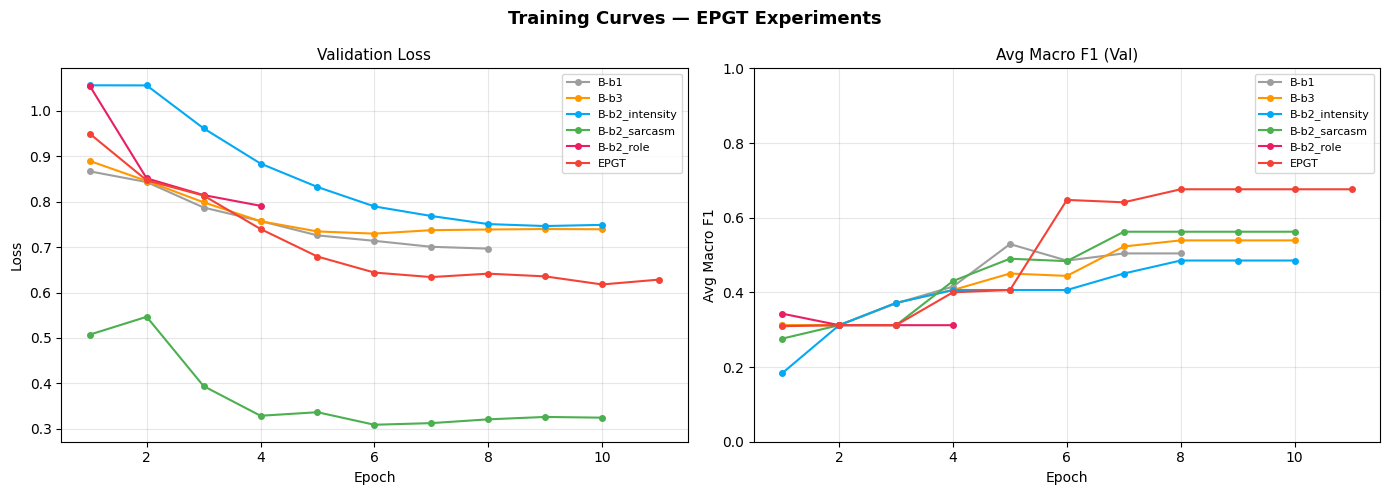

Training curves saved: /content/drive/MyDrive/EPGT_Research/outputs/figures/training_curves.png


In [18]:
# ============================================================
# CELL 6.2 — Visualisasi Training Curves
# ============================================================

import json
import matplotlib.pyplot as plt

# Load training logs
run_names = [
    "baseline_b1", "baseline_b3",
    "baseline_b2_intensity", "baseline_b2_sarcasm", "baseline_b2_role",
    "epgt_full"
]
colors = [
    "#9E9E9E", "#FF9800",
    "#03A9F4", "#4CAF50", "#E91E63",
    "#F44336"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Curves — EPGT Experiments", fontsize=13, fontweight="bold")

for run_name, color in zip(run_names, colors):
    log_path = DRIVE_ROOT / f"checkpoints/{run_name}/training_log.json"
    if not log_path.exists():
        continue
    with open(log_path) as f:
        log = json.load(f)

    epochs    = [e["epoch"]         for e in log]
    val_loss  = [e["val_loss"]       for e in log]
    avg_f1    = [e["avg_macro_f1"]   for e in log]

    label = run_name.replace("baseline_", "B-").replace("epgt_full", "EPGT")
    axes[0].plot(epochs, val_loss, marker="o", markersize=4,
                 color=color, label=label, linewidth=1.5)
    axes[1].plot(epochs, avg_f1, marker="o", markersize=4,
                 color=color, label=label, linewidth=1.5)

axes[0].set_title("Validation Loss",     fontsize=11)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_title("Avg Macro F1 (Val)", fontsize=11)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Avg Macro F1")
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()

fig_path = DRIVE_ROOT / "outputs/figures/training_curves.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Training curves saved: {fig_path}")

---
## BAGIAN 7 — NB05 COMPLETION REPORT

In [19]:
# ============================================================
# CELL 7.1 — NB05 Completion Report
# ============================================================

from pathlib import Path

print("=" * 60)
print("NB05 COMPLETION REPORT")
print("EPGT Research — Training Pipeline & Baseline Training")
print("=" * 60)

print("\n[1] SOURCE FILES")
src_files = [
    "src/training/loss.py",
    "src/training/metrics.py",
    "src/training/trainer.py",
    "src/data/dataset.py",
]
for f in src_files:
    p  = DRIVE_ROOT / f
    ok = p.exists()
    print(f"  {'OK' if ok else 'MISSING':>7}  {f}")

print("\n[2] CHECKPOINTS")
runs = [
    "baseline_b1", "baseline_b2_intensity", "baseline_b2_sarcasm",
    "baseline_b2_role", "baseline_b3", "epgt_full"
]
for run in runs:
    ckpt_path = DRIVE_ROOT / f"checkpoints/{run}/best_model.pt"
    log_path  = DRIVE_ROOT / f"checkpoints/{run}/training_log.json"
    ok_ckpt   = ckpt_path.exists()
    ok_log    = log_path.exists()
    best_f1   = ""
    if ok_log:
        with open(log_path) as f:
            log   = json.load(f)
            if log:
                best_f1 = f"best_f1={max(e['avg_macro_f1'] for e in log):.4f}"
    status = "OK" if ok_ckpt and ok_log else "MISSING"
    print(f"  {status:>7}  {run:<30} {best_f1}")

print("\n[3] TRAINING CONFIGURATION")
print(f"  Optimizer     : AdamW (lr=2e-5, wd=0.01)")
print(f"  Scheduler     : Linear warmup (ratio=0.10)")
print(f"  MTL Loss      : λ_A=0.40 λ_B=0.35 λ_C=0.25")
print(f"  Early stopping: patience=3, monitor=avg_macro_f1")
print(f"  Grad clip     : max_norm=1.0")
print(f"  Batch size    : {BATCH_SIZE}")

print("\n[4] NEXT STEP")
print("  → NB06: Evaluation & Ablation Study")
print("    Test set evaluation, classification reports,")
print("    ablation table, attention visualization.")
print("\n" + "=" * 60)

NB05 COMPLETION REPORT
EPGT Research — Training Pipeline & Baseline Training

[1] SOURCE FILES
       OK  src/training/loss.py
       OK  src/training/metrics.py
       OK  src/training/trainer.py
       OK  src/data/dataset.py

[2] CHECKPOINTS
       OK  baseline_b1                    best_f1=0.5293
       OK  baseline_b2_intensity          best_f1=0.4853
       OK  baseline_b2_sarcasm            best_f1=0.5624
       OK  baseline_b2_role               best_f1=0.3430
       OK  baseline_b3                    best_f1=0.5392
       OK  epgt_full                      best_f1=0.6761

[3] TRAINING CONFIGURATION
  Optimizer     : AdamW (lr=2e-5, wd=0.01)
  Scheduler     : Linear warmup (ratio=0.10)
  MTL Loss      : λ_A=0.40 λ_B=0.35 λ_C=0.25
  Early stopping: patience=3, monitor=avg_macro_f1
  Grad clip     : max_norm=1.0
  Batch size    : 16

[4] NEXT STEP
  → NB06: Evaluation & Ablation Study
    Test set evaluation, classification reports,
    ablation table, attention visualization.

